In [1]:
import numpy as np
import scipy.sparse as sp
import faiss
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment
from sklearn.model_selection import train_test_split

import sys
from pathlib import Path
root = Path.cwd()
if not (root / "modules").is_dir():
    REPO_ROOT = root.parent
sys.path.insert(0, str(REPO_ROOT))
from utilities.utils import *
from utilities.data_loader import load_embeddings

In [2]:
def balanced_subset(
    X,
    y,
    max_samples=10000,
    random_state=42
):
    """
    Create a class-balanced subset.

    Parameters
    ----------
    X : np.ndarray
        Embeddings/features

    y : np.ndarray
        Labels

    max_samples : int
        Total subset size

    Returns
    -------
    X_sub, y_sub
    """

    X_sub, _, y_sub, _ = train_test_split(
        X,
        y,
        train_size=max_samples,
        stratify=y,
        random_state=random_state
    )

    return X_sub, y_sub

def target_distribution(q):
    weight = (q ** 2) / torch.sum(q, dim=0)
    return (weight.t() / torch.sum(weight, dim=1)).t()


def cluster_delta(y_prev, y_curr):
    cm = confusion_matrix(y_prev, y_curr)
    row_ind, col_ind = linear_sum_assignment(-cm)
    matched = cm[row_ind, col_ind].sum()
    return 1 - matched / len(y_prev)


def build_knn_graph(
    X,
    topk=10,
    metric="cosine"
):
    """
    Unified graph construction for BOTH:
    - TF-IDF + PCA/SVD
    - SBERT embeddings

    Uses cosine similarity by default.
    """

    X = X.astype(np.float32).copy()

    N, d = X.shape

    if metric == "cosine":

        faiss.normalize_L2(X)

        index = faiss.IndexFlatIP(d)

    elif metric == "euclidean":

        index = faiss.IndexFlatL2(d)

    else:
        raise ValueError(f"Unsupported metric: {metric}")

    index.add(X)

    sims, indices = index.search(X, topk + 1)

    rows = []
    cols = []
    vals = []

    for i in range(N):

        for j, sim in zip(indices[i][1:], sims[i][1:]):

            rows.append(i)
            cols.append(j)

            if metric == "euclidean":
                sim = np.exp(-sim)

            vals.append(float(sim))

    adj = sp.coo_matrix(
        (vals, (rows, cols)),
        shape=(N, N),
        dtype=np.float32
    )

    # Symmetrize
    adj = adj.maximum(adj.T)

    # Self-loops
    adj = adj + sp.eye(adj.shape[0], dtype=np.float32)

    deg = np.array(adj.sum(1)).flatten()

    deg_inv_sqrt = 1.0 / np.sqrt(deg + 1e-10)

    D_inv_sqrt = sp.diags(deg_inv_sqrt)

    adj = D_inv_sqrt @ adj @ D_inv_sqrt

    adj = adj.tocsr()
    adj.eliminate_zeros()

    return adj


def sparse_to_torch(adj):

    adj = adj.tocoo()

    indices = torch.from_numpy(
        np.vstack((adj.row, adj.col))
    ).long()

    values = torch.from_numpy(adj.data).float()

    shape = torch.Size(adj.shape)

    return torch.sparse_coo_tensor(
        indices,
        values,
        shape
    )


class AE(nn.Module):
    def __init__(self, n_input, n_enc_1=256, n_enc_2=128, n_enc_3=64, n_z=64):
        super().__init__()

        self.enc_1 = nn.Linear(n_input, n_enc_1)
        self.enc_2 = nn.Linear(n_enc_1, n_enc_2)
        self.enc_3 = nn.Linear(n_enc_2, n_enc_3)
        self.z_layer = nn.Linear(n_enc_3, n_z)

        self.dec_1 = nn.Linear(n_z, n_enc_3)
        self.dec_2 = nn.Linear(n_enc_3, n_enc_2)
        self.dec_3 = nn.Linear(n_enc_2, n_enc_1)
        self.x_bar = nn.Linear(n_enc_1, n_input)

    def forward(self, x):
        h1 = F.relu(self.enc_1(x))
        h2 = F.relu(self.enc_2(h1))
        h3 = F.relu(self.enc_3(h2))
        z = self.z_layer(h3)

        d1 = F.relu(self.dec_1(z))
        d2 = F.relu(self.dec_2(d1))
        d3 = F.relu(self.dec_3(d2))
        x_hat = self.x_bar(d3)

        return x_hat, h1, h2, h3, z


class GCNLayer(nn.Module):

    def __init__(self, in_dim, out_dim):

        super().__init__()

        self.linear = nn.Linear(in_dim, out_dim)

    def forward(self, x, adj, active=True):

        x = self.linear(x)

        x = torch.sparse.mm(adj, x)

        if active:
            x = F.relu(x)

        return x


class SDCN(nn.Module):
    def __init__(self, n_input, n_z, n_clusters, sigma):
        super().__init__()

        self.sigma = sigma

        # AE
        self.ae = AE(n_input=n_input, n_z=n_z)

        # GCN
        self.gnn_1 = GCNLayer(n_input, 256)
        self.gnn_2 = GCNLayer(256, 128)
        self.gnn_3 = GCNLayer(128, 64)
        self.gnn_4 = GCNLayer(64, n_z)
        self.gnn_5 = GCNLayer(n_z, n_clusters)

        # clustering
        self.cluster_layer = nn.Parameter(torch.Tensor(n_clusters, n_z))
        nn.init.xavier_normal_(self.cluster_layer.data)

        self.v = 1.0

    def soft_assign(self, z):
        dist = torch.sum((z.unsqueeze(1) - self.cluster_layer) ** 2, dim=2)
        q = 1.0 / (1.0 + dist / self.v)
        q = q ** ((self.v + 1.0) / 2.0)
        return q / q.sum(dim=1, keepdim=True)

    def forward(self, x, adj):
        # AE forward
        x_bar, h1, h2, h3, z = self.ae(x)

        sigma = self.sigma

        # GCN with fusion
        h = self.gnn_1(x, adj)
        h = self.gnn_2((1 - sigma) * h + sigma * h1, adj)
        h = self.gnn_3((1 - sigma) * h + sigma * h2, adj)
        h = self.gnn_4((1 - sigma) * h + sigma * h3, adj)
        h = self.gnn_5((1 - sigma) * h + sigma * z, adj, active=False)

        predict = F.log_softmax(h, dim=1)

        # AE clustering
        q = self.soft_assign(z)

        return x_bar, q, predict, z


class SDCNClusterer:

    def __init__(
        self,
        device="cuda",
        latent_dim=64,
        knn_k=10,
        sigma=0.5,
        alpha=0.1,
        beta=1.0,
        lr=1e-3,
        pretrain_epochs=100,
        epochs=200,
        update_interval=10,
        tol=1e-3,
        use_pca=False
    ):

        self.device = device
        self.latent_dim = latent_dim

        self.knn_k = knn_k

        self.sigma = sigma

        self.alpha = alpha
        self.beta = beta

        self.lr = lr

        self.pretrain_epochs = pretrain_epochs
        self.epochs = epochs

        self.update_interval = update_interval
        self.tol = tol

        self.use_pca = use_pca

        self.training_history = []

    def fit_predict(
        self,
        embeddings,
        k,
        true_labels=None
    ):

        torch.manual_seed(42)
        np.random.seed(42)

        self.training_history = []

        best_metrics = {
            "epoch": -1,
            "NMI": -1,
            "ARI": -1,
            "ACC": -1,
            "Purity": -1
        }

        device = torch.device(self.device)

        # Optional PCA

        X_np = embeddings.astype(np.float32)

        # Build graph

        adj = build_knn_graph(
            X_np,
            topk=self.knn_k,
            metric="cosine"
        )

        # Diagnostics

        density = adj.nnz / (adj.shape[0] ** 2)

        print(f"[Graph] Nodes: {adj.shape[0]}")
        print(f"[Graph] Edges: {adj.nnz}")
        print(f"[Graph] Density: {density:.8f}")

        self.training_history.append({
            "stage": "graph",
            "nodes": int(adj.shape[0]),
            "edges": int(adj.nnz),
            "density": float(density),
            "knn_k": int(self.knn_k)
        })

        # Torch tensors

        X = torch.tensor(
            X_np,
            dtype=torch.float32,
            device=device
        )

        adj = sparse_to_torch(adj).coalesce().to(device)

        if torch.isnan(X).any():
            raise ValueError("Input embeddings contain NaNs")

        if adj._values().numel() > 0 and torch.isnan(adj._values()).any():
            raise ValueError("Adjacency matrix contains NaNs")

        # Model

        model = SDCN(
            n_input=X.shape[1],
            n_z=self.latent_dim,
            n_clusters=k,
            sigma=self.sigma
        ).to(device)

        # AE pretraining

        optimizer_ae = torch.optim.Adam(
            model.ae.parameters(),
            lr=self.lr
        )

        print("\n[SDCN] Pretraining AE...\n")

        model.train()

        for epoch in range(self.pretrain_epochs):

            x_hat, *_ = model.ae(X)

            loss = F.mse_loss(x_hat, X)

            optimizer_ae.zero_grad()

            loss.backward()

            optimizer_ae.step()

            self.training_history.append({
                "stage": "pretrain",
                "epoch": int(epoch),
                "reconstruction_loss": float(loss.item())
            })

        # KMeans init

        model.eval()

        with torch.no_grad():

            _, _, _, _, z = model.ae(X)

        z_np = z.detach().cpu().numpy()

        kmeans = KMeans(
            n_clusters=k,
            n_init=20,
            random_state=42
        )

        y_pred = kmeans.fit_predict(z_np)

        y_pred_last = y_pred.copy()

        model.cluster_layer.data = torch.tensor(
            kmeans.cluster_centers_,
            dtype=torch.float32,
            device=device
        )

        model.train()

        # Joint training

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=self.lr
        )

        print("\n[SDCN] Joint Training...\n")

        model.train()

        kl_base = None
        gcn_kl_base = None
        re_base = None

        for epoch in range(self.epochs):

            x_bar, q, pred, z = model(X, adj)

            q = q.clamp(min=1e-10)

            p = target_distribution(q).detach()

            # Losses
            kl_loss = F.kl_div(
                q.log(),
                p,
                reduction="batchmean"
            )

            gcn_kl_loss = F.kl_div(
                pred,
                p,
                reduction="batchmean",
                log_target=False
            )

            re_loss = F.mse_loss(x_bar, X)

            if epoch == 0:

                kl_base = kl_loss.detach()

                gcn_kl_base = gcn_kl_loss.detach()

                re_base = re_loss.detach()

            loss = (

                self.alpha * (kl_loss / (kl_base + 1e-8)) +

                self.beta * (gcn_kl_loss / (gcn_kl_base + 1e-8)) +

                (re_loss / (re_base + 1e-8))

            )

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            # ---------------------------------------------
            # Convergence
            # ---------------------------------------------
            delta = None

            if epoch % self.update_interval == 0:

                with torch.no_grad():

                    y_pred = q.argmax(1).cpu().numpy()

                    delta = cluster_delta(
                        y_pred_last,
                        y_pred
                    )

                    y_pred_last = y_pred.copy()

                if true_labels is not None:

                    metrics = get_metrics(
                        X_np,
                        true_labels,
                        y_pred
                    )

                    self.training_history.append({
                        "stage": "eval",
                        "epoch": int(epoch),
                        "NMI": float(metrics["NMI"]),
                        "ARI": float(metrics["ARI"]),
                        "ACC": float(metrics["Accuracy"]),
                        "Purity": float(metrics["Purity"])
                    })

                    # Track best metrics
                    if metrics["Accuracy"] > best_metrics["ACC"]:

                        best_metrics = {
                            "epoch": int(epoch),
                            "NMI": float(metrics["NMI"]),
                            "ARI": float(metrics["ARI"]),
                            "ACC": float(metrics["Accuracy"]),
                            "Purity": float(metrics["Purity"])
                        }

                if epoch > 20 and delta < self.tol:

                    print(f"[SDCN] Converged at epoch {epoch}")

                    self.training_history.append({
                        "stage": "cluster",
                        "epoch": int(epoch),
                        "loss": float(loss.item()),
                        "kl_loss": float(kl_loss.item()),
                        "gcn_kl_loss": float(gcn_kl_loss.item()),
                        "reconstruction_loss": float(re_loss.item()),
                        "delta": float(delta),
                        "converged": True
                    })

                    break

            # ---------------------------------------------
            # Logging
            # ---------------------------------------------
            self.training_history.append({
                "stage": "cluster",
                "epoch": int(epoch),
                "loss": float(loss.item()),
                "kl_loss": float(kl_loss.item()),
                "gcn_kl_loss": float(gcn_kl_loss.item()),
                "reconstruction_loss": float(re_loss.item()),
                "delta": None if delta is None else float(delta)
            })

            if epoch % 10 == 0:

                print(
                    f"[SDCN] Epoch {epoch} | "
                    f"Loss={loss.item():.4f} | "
                    f"KL={kl_loss.item():.4f} | "
                    f"GCN_KL={gcn_kl_loss.item():.4f} | "
                    f"RE={re_loss.item():.4f}"
                )

        # Final prediction
        model.eval()
        with torch.no_grad():

            _, q, _, _ = model(X, adj)

            labels = q.argmax(1).cpu().numpy()

        if true_labels is not None:
            final_metrics = get_metrics(
                X_np,
                true_labels,
                labels
            )

            self.training_history.append({
                "stage": "final",
                "NMI": float(final_metrics["NMI"]),
                "ARI": float(final_metrics["ARI"]),
                "ACC": float(final_metrics["Accuracy"]),
                "Purity": float(final_metrics["Purity"])
            })

            self.training_history.append({
                "stage": "best",
                **best_metrics
            })

        return labels, self.training_history

In [3]:
def run_sdcn(
    X,
    n_clusters,
    device,
    y_true=None,
    dataset_name="unknown"
):

    model = SDCNClusterer(
        device=device,
        latent_dim=64,
        knn_k=5,
        sigma=0.5,
        alpha=0.1,
        beta=1.0,
        lr=1e-3,
        pretrain_epochs=100,
        epochs=200,
        update_interval=10,
        tol=1e-3,
        use_pca=False
    )

    y_pred, history = model.fit_predict(
        embeddings=X,
        k=n_clusters,
        true_labels=y_true
    )

    return y_pred, history


def run_experiments(datasets_root, csv_path):

    datasets = list(Path(datasets_root).glob("*.npz"))

    history_dict = {}

    for dataset_path in datasets:

        encoder_name = dataset_path.stem.split("_")[2]

        dataset_name = dataset_path.stem.replace(
            "emb_", ""
        ).replace(f"_{encoder_name}", "")

        print(
            f"\nRunning dataset: {dataset_name} "
            f"with encoder: {encoder_name}"
        )

        X, y, texts = load_embeddings(dataset_path)

        if len(X) > 20000:
            print(f"[Subset] Reducing dataset from {len(X)} to 20000")
        
            X, y = balanced_subset(
        
                X,
        
                y,
        
                max_samples=20000
        
            )

        X_reduced, pca = pca_by_variance(X)

        pca_components = pca.n_components_

        k_true = len(set(y))

        y_pred, history = run_sdcn(
            X=X_reduced,
            n_clusters=k_true,
            device=get_device(),
            y_true=y,
            dataset_name=dataset_name
        )

        history_dict[
            dataset_name + "_" + encoder_name
        ] = history

        metrics = get_metrics(
            X_reduced,
            y,
            y_pred
        )

        plot_and_save_clusters(
            dataset=dataset_name,
            encoder_name=encoder_name,
            clusterer="SDCN",
            X=X_reduced,
            y_pred=y_pred,
            n_clusters=k_true,
            number_of_components=pca_components
        )

        log_experiment(
            csv_path=csv_path,
            model_name="SDCN",
            dataset_name=dataset_name,
            encoder_name=encoder_name,
            n_rows=len(X_reduced),
            pca_components=pca_components,
            nmi=metrics["NMI"],
            ari=metrics["ARI"],
            acc=metrics["Accuracy"],
            purity=metrics["Purity"]
        )

    return history_dict


Running dataset: agnews with encoder: sbert
[Subset] Reducing dataset from 127600 to 20000
[Graph] Nodes: 20000
[Graph] Edges: 168712
[Graph] Density: 0.00042178

[SDCN] Pretraining AE...


[SDCN] Joint Training...

[SDCN] Epoch 0 | Loss=2.1000 | KL=0.0798 | GCN_KL=0.3533 | RE=0.0030
[SDCN] Epoch 10 | Loss=2.2202 | KL=0.1026 | GCN_KL=0.3872 | RE=0.0030
[SDCN] Epoch 20 | Loss=1.7243 | KL=0.0894 | GCN_KL=0.2192 | RE=0.0030
[SDCN] Epoch 30 | Loss=1.2952 | KL=0.0648 | GCN_KL=0.0802 | RE=0.0030
[SDCN] Epoch 40 | Loss=1.1992 | KL=0.0652 | GCN_KL=0.0504 | RE=0.0030
[SDCN] Epoch 50 | Loss=1.2071 | KL=0.0769 | GCN_KL=0.0521 | RE=0.0029
[SDCN] Epoch 60 | Loss=1.2195 | KL=0.0904 | GCN_KL=0.0547 | RE=0.0029
[SDCN] Epoch 70 | Loss=1.2490 | KL=0.1083 | GCN_KL=0.0610 | RE=0.0029
[SDCN] Epoch 80 | Loss=1.2651 | KL=0.1251 | GCN_KL=0.0635 | RE=0.0028
[SDCN] Epoch 90 | Loss=1.2895 | KL=0.1392 | GCN_KL=0.0691 | RE=0.0028
[SDCN] Epoch 100 | Loss=1.2962 | KL=0.1460 | GCN_KL=0.0700 | RE=0.0028
[SDCN] Epoch 

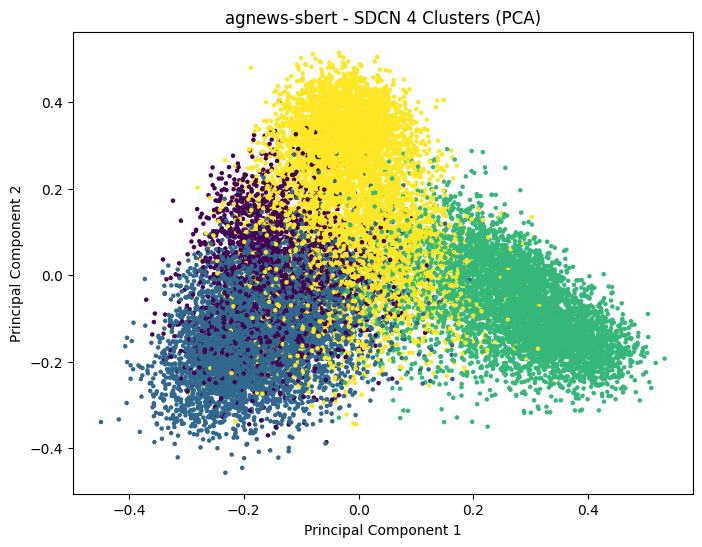


Running dataset: dbpedia with encoder: sbert
[Subset] Reducing dataset from 150000 to 20000
[Graph] Nodes: 20000
[Graph] Edges: 172550
[Graph] Density: 0.00043138

[SDCN] Pretraining AE...


[SDCN] Joint Training...

[SDCN] Epoch 0 | Loss=2.1000 | KL=0.1395 | GCN_KL=0.5859 | RE=0.0030
[SDCN] Epoch 10 | Loss=2.1853 | KL=0.1576 | GCN_KL=0.6207 | RE=0.0030
[SDCN] Epoch 20 | Loss=2.1259 | KL=0.1663 | GCN_KL=0.5988 | RE=0.0030
[SDCN] Epoch 30 | Loss=1.8873 | KL=0.1574 | GCN_KL=0.4725 | RE=0.0029
[SDCN] Epoch 40 | Loss=1.4694 | KL=0.1226 | GCN_KL=0.2491 | RE=0.0029
[SDCN] Epoch 50 | Loss=1.2071 | KL=0.0948 | GCN_KL=0.1135 | RE=0.0028
[SDCN] Epoch 60 | Loss=1.1277 | KL=0.0968 | GCN_KL=0.0741 | RE=0.0028
[SDCN] Epoch 70 | Loss=1.1269 | KL=0.1143 | GCN_KL=0.0744 | RE=0.0028
[SDCN] Epoch 80 | Loss=1.1707 | KL=0.1443 | GCN_KL=0.0951 | RE=0.0027
[SDCN] Epoch 90 | Loss=1.2094 | KL=0.1761 | GCN_KL=0.1107 | RE=0.0027
[SDCN] Epoch 100 | Loss=1.2234 | KL=0.2024 | GCN_KL=0.1123 | RE=0.0027
[SDCN] Epoch

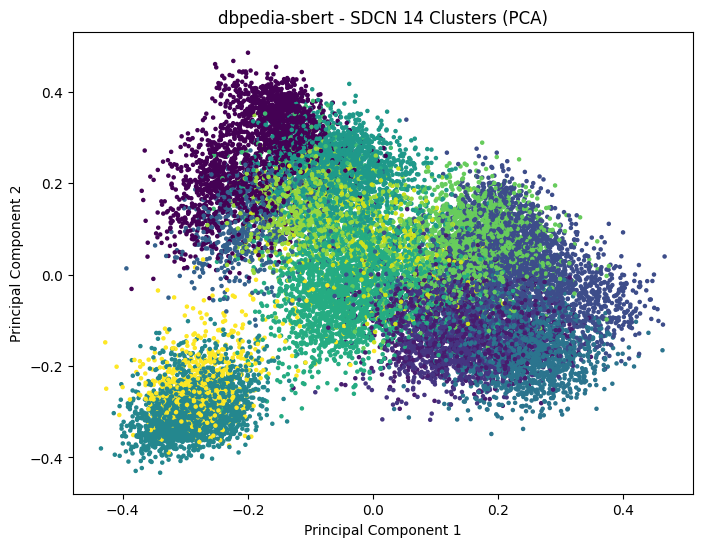


Running dataset: reuters with encoder: sbert
[Graph] Nodes: 7674
[Graph] Edges: 66564
[Graph] Density: 0.00113031

[SDCN] Pretraining AE...


[SDCN] Joint Training...

[SDCN] Epoch 0 | Loss=2.1000 | KL=0.1439 | GCN_KL=0.7052 | RE=0.0025
[SDCN] Epoch 10 | Loss=2.1021 | KL=0.1557 | GCN_KL=0.7054 | RE=0.0025
[SDCN] Epoch 20 | Loss=1.9205 | KL=0.1494 | GCN_KL=0.5893 | RE=0.0025
[SDCN] Epoch 30 | Loss=1.5876 | KL=0.1282 | GCN_KL=0.3742 | RE=0.0025
[SDCN] Epoch 40 | Loss=1.2649 | KL=0.1024 | GCN_KL=0.1679 | RE=0.0024
[SDCN] Epoch 50 | Loss=1.1538 | KL=0.0959 | GCN_KL=0.1027 | RE=0.0024
[SDCN] Epoch 60 | Loss=1.1466 | KL=0.1077 | GCN_KL=0.1026 | RE=0.0024
[SDCN] Epoch 70 | Loss=1.1510 | KL=0.1238 | GCN_KL=0.1138 | RE=0.0023
[SDCN] Epoch 80 | Loss=1.1782 | KL=0.1430 | GCN_KL=0.1364 | RE=0.0023
[SDCN] Epoch 90 | Loss=1.1848 | KL=0.1578 | GCN_KL=0.1418 | RE=0.0022
[SDCN] Epoch 100 | Loss=1.1724 | KL=0.1684 | GCN_KL=0.1330 | RE=0.0022
[SDCN] Epoch 110 | Loss=1.1593 | KL=0.1769 | GCN_KL=0.1253 | 

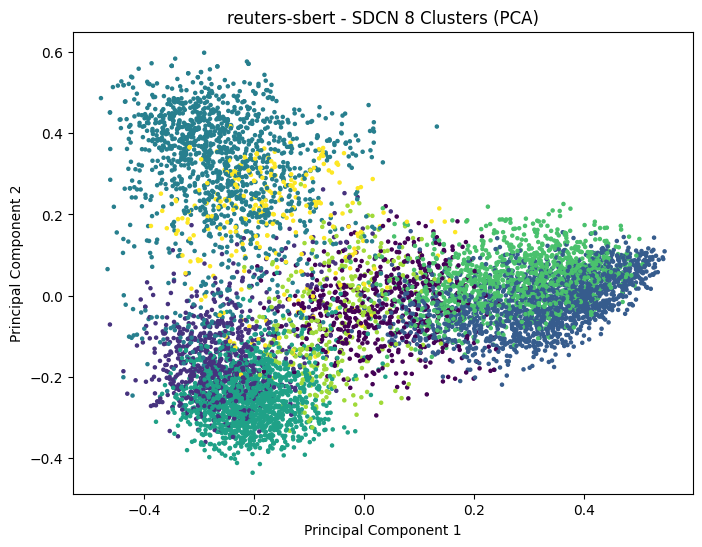


Running dataset: bbcnews with encoder: sbert
[Graph] Nodes: 2225
[Graph] Edges: 18453
[Graph] Density: 0.00372741

[SDCN] Pretraining AE...


[SDCN] Joint Training...

[SDCN] Epoch 0 | Loss=2.1000 | KL=0.1465 | GCN_KL=0.6917 | RE=0.0029
[SDCN] Epoch 10 | Loss=2.1023 | KL=0.1641 | GCN_KL=0.6829 | RE=0.0029
[SDCN] Epoch 20 | Loss=1.8554 | KL=0.1635 | GCN_KL=0.5311 | RE=0.0028
[SDCN] Epoch 30 | Loss=1.4543 | KL=0.1396 | GCN_KL=0.2836 | RE=0.0027
[SDCN] Epoch 40 | Loss=1.1629 | KL=0.1130 | GCN_KL=0.1124 | RE=0.0026
[SDCN] Epoch 50 | Loss=1.0764 | KL=0.1109 | GCN_KL=0.0714 | RE=0.0026
[SDCN] Epoch 60 | Loss=1.0784 | KL=0.1308 | GCN_KL=0.0804 | RE=0.0025
[SDCN] Epoch 70 | Loss=1.0797 | KL=0.1507 | GCN_KL=0.0866 | RE=0.0024
[SDCN] Epoch 80 | Loss=1.0682 | KL=0.1690 | GCN_KL=0.0820 | RE=0.0024
[SDCN] Epoch 90 | Loss=1.0609 | KL=0.1875 | GCN_KL=0.0790 | RE=0.0023
[SDCN] Epoch 100 | Loss=1.0439 | KL=0.1971 | GCN_KL=0.0724 | RE=0.0023
[SDCN] Epoch 110 | Loss=1.0233 | KL=0.1978 | GCN_KL=0.0659 | 

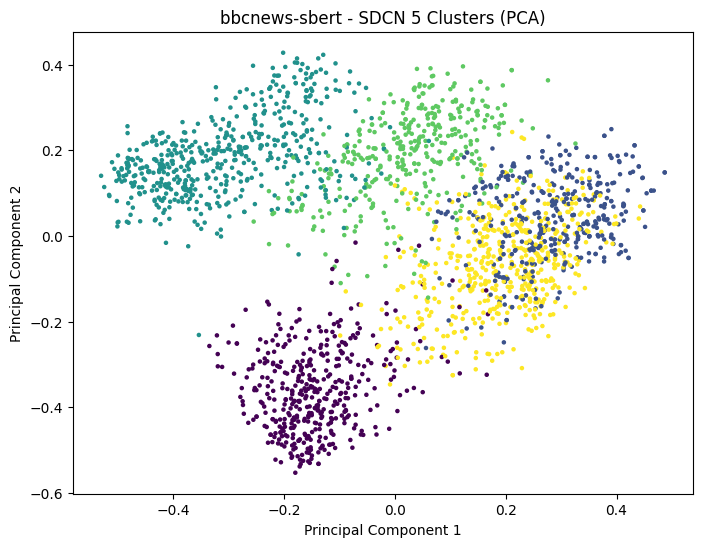


Running dataset: 20newsgroups with encoder: tfidf
[Graph] Nodes: 18331
[Graph] Edges: 172413
[Graph] Density: 0.00051309

[SDCN] Pretraining AE...


[SDCN] Joint Training...

[SDCN] Epoch 0 | Loss=2.1000 | KL=0.0196 | GCN_KL=0.0829 | RE=0.0032
[SDCN] Epoch 10 | Loss=3.1968 | KL=0.0440 | GCN_KL=0.1635 | RE=0.0032
[SDCN] Epoch 20 | Loss=2.6959 | KL=0.0412 | GCN_KL=0.1228 | RE=0.0032
[SDCN] Epoch 30 | Loss=2.0108 | KL=0.0322 | GCN_KL=0.0695 | RE=0.0032
[SDCN] Epoch 40 | Loss=2.1294 | KL=0.0400 | GCN_KL=0.0760 | RE=0.0032
[SDCN] Epoch 50 | Loss=2.2220 | KL=0.0452 | GCN_KL=0.0819 | RE=0.0032
[SDCN] Epoch 60 | Loss=2.4750 | KL=0.0558 | GCN_KL=0.0990 | RE=0.0032
[SDCN] Epoch 70 | Loss=2.8329 | KL=0.0680 | GCN_KL=0.1239 | RE=0.0031
[SDCN] Epoch 80 | Loss=3.3126 | KL=0.0806 | GCN_KL=0.1586 | RE=0.0031
[SDCN] Epoch 90 | Loss=3.9381 | KL=0.0943 | GCN_KL=0.2045 | RE=0.0031
[SDCN] Epoch 100 | Loss=4.6454 | KL=0.1071 | GCN_KL=0.2576 | RE=0.0031
[SDCN] Epoch 110 | Loss=5.3049 | KL=0.1189 | GCN_KL=0.

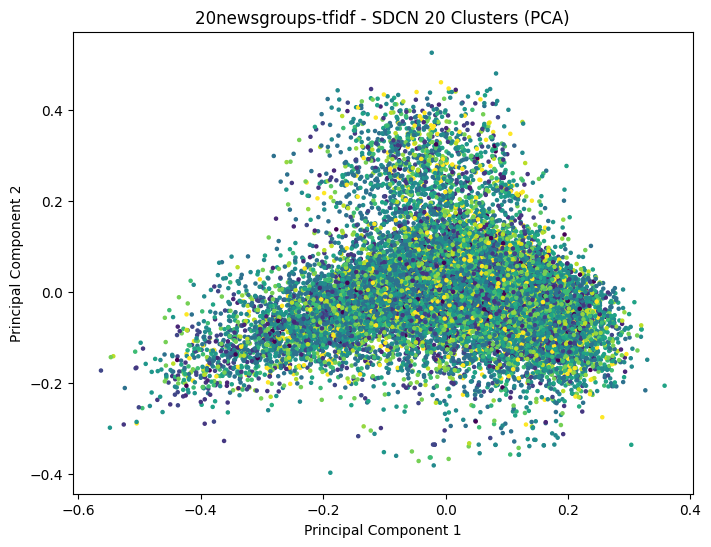


Running dataset: dbpedia with encoder: tfidf
[Subset] Reducing dataset from 150000 to 20000
[Graph] Nodes: 20000
[Graph] Edges: 180972
[Graph] Density: 0.00045243

[SDCN] Pretraining AE...


[SDCN] Joint Training...

[SDCN] Epoch 0 | Loss=2.1000 | KL=0.1161 | GCN_KL=0.4762 | RE=0.0033
[SDCN] Epoch 10 | Loss=2.2038 | KL=0.1451 | GCN_KL=0.5304 | RE=0.0031
[SDCN] Epoch 20 | Loss=2.0718 | KL=0.1555 | GCN_KL=0.4774 | RE=0.0030
[SDCN] Epoch 30 | Loss=1.5993 | KL=0.1224 | GCN_KL=0.2783 | RE=0.0030
[SDCN] Epoch 40 | Loss=1.2568 | KL=0.0894 | GCN_KL=0.1384 | RE=0.0029
[SDCN] Epoch 50 | Loss=1.1811 | KL=0.0933 | GCN_KL=0.1124 | RE=0.0028
[SDCN] Epoch 60 | Loss=1.1531 | KL=0.1048 | GCN_KL=0.1054 | RE=0.0027
[SDCN] Epoch 70 | Loss=1.1437 | KL=0.1209 | GCN_KL=0.1050 | RE=0.0027
[SDCN] Epoch 80 | Loss=1.1688 | KL=0.1438 | GCN_KL=0.1161 | RE=0.0026
[SDCN] Epoch 90 | Loss=1.1749 | KL=0.1628 | GCN_KL=0.1200 | RE=0.0026
[SDCN] Epoch 100 | Loss=1.1938 | KL=0.1838 | GCN_KL=0.1260 | RE=0.0025
[SDCN] Epoch

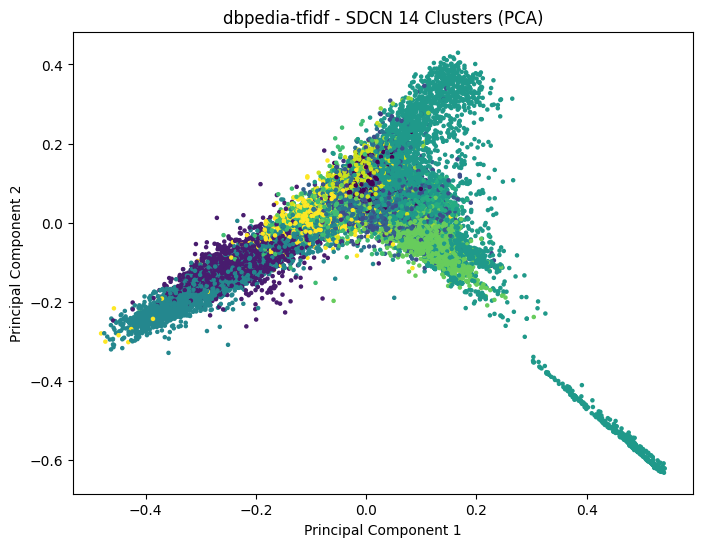


Running dataset: reuters with encoder: tfidf
[Graph] Nodes: 7674
[Graph] Edges: 65146
[Graph] Density: 0.00110623

[SDCN] Pretraining AE...


[SDCN] Joint Training...

[SDCN] Epoch 0 | Loss=2.1000 | KL=0.1428 | GCN_KL=0.8302 | RE=0.0031
[SDCN] Epoch 10 | Loss=2.0559 | KL=0.1529 | GCN_KL=0.7971 | RE=0.0030
[SDCN] Epoch 20 | Loss=1.6782 | KL=0.1328 | GCN_KL=0.5107 | RE=0.0030
[SDCN] Epoch 30 | Loss=1.2725 | KL=0.0986 | GCN_KL=0.2063 | RE=0.0029
[SDCN] Epoch 40 | Loss=1.1649 | KL=0.0925 | GCN_KL=0.1364 | RE=0.0029
[SDCN] Epoch 50 | Loss=1.1364 | KL=0.0974 | GCN_KL=0.1283 | RE=0.0028
[SDCN] Epoch 60 | Loss=1.0880 | KL=0.0988 | GCN_KL=0.1055 | RE=0.0028
[SDCN] Epoch 70 | Loss=1.0534 | KL=0.0987 | GCN_KL=0.0925 | RE=0.0027
[SDCN] Epoch 80 | Loss=1.1150 | KL=0.1166 | GCN_KL=0.1443 | RE=0.0027
[SDCN] Epoch 90 | Loss=1.1800 | KL=0.1426 | GCN_KL=0.1827 | RE=0.0027
[SDCN] Epoch 100 | Loss=1.1668 | KL=0.1553 | GCN_KL=0.1655 | RE=0.0026
[SDCN] Epoch 110 | Loss=1.1599 | KL=0.1610 | GCN_KL=0.1673 | 

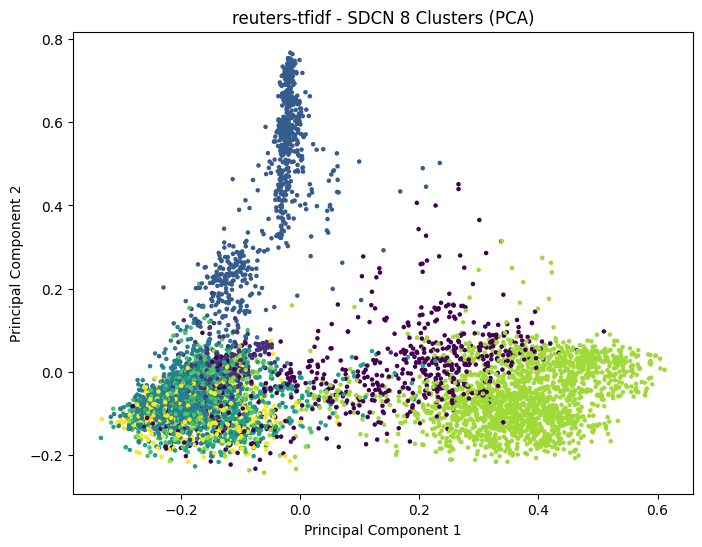


Running dataset: bbcnews with encoder: tfidf
[Graph] Nodes: 2225
[Graph] Edges: 17495
[Graph] Density: 0.00353390

[SDCN] Pretraining AE...


[SDCN] Joint Training...

[SDCN] Epoch 0 | Loss=2.1000 | KL=0.0688 | GCN_KL=0.2979 | RE=0.0031
[SDCN] Epoch 10 | Loss=2.3866 | KL=0.1023 | GCN_KL=0.3740 | RE=0.0030
[SDCN] Epoch 20 | Loss=1.8766 | KL=0.0935 | GCN_KL=0.2290 | RE=0.0030
[SDCN] Epoch 30 | Loss=1.2475 | KL=0.0576 | GCN_KL=0.0604 | RE=0.0030
[SDCN] Epoch 40 | Loss=1.1739 | KL=0.0596 | GCN_KL=0.0416 | RE=0.0029
[SDCN] Epoch 50 | Loss=1.1906 | KL=0.0718 | GCN_KL=0.0473 | RE=0.0029
[SDCN] Epoch 60 | Loss=1.1904 | KL=0.0815 | GCN_KL=0.0493 | RE=0.0028
[SDCN] Epoch 70 | Loss=1.2229 | KL=0.0973 | GCN_KL=0.0577 | RE=0.0028
[SDCN] Epoch 80 | Loss=1.2677 | KL=0.1175 | GCN_KL=0.0675 | RE=0.0027
[SDCN] Epoch 90 | Loss=1.3149 | KL=0.1405 | GCN_KL=0.0764 | RE=0.0026
[SDCN] Epoch 100 | Loss=1.3338 | KL=0.1558 | GCN_KL=0.0777 | RE=0.0026
[SDCN] Epoch 110 | Loss=1.3489 | KL=0.1633 | GCN_KL=0.0812 | 

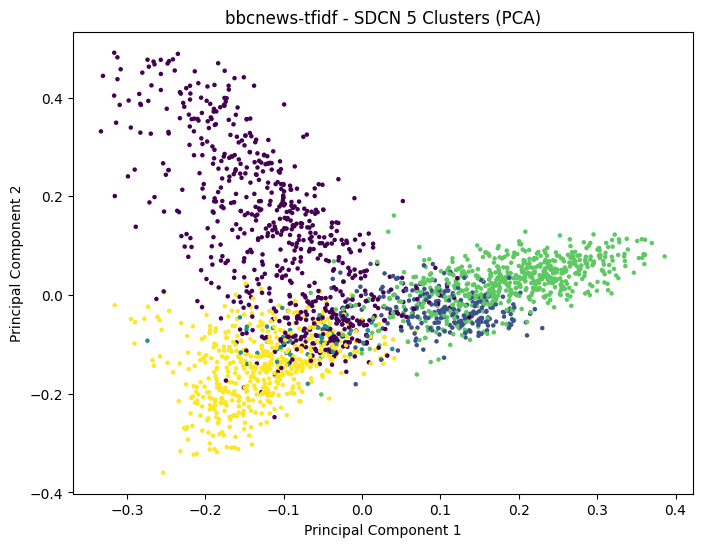


Running dataset: 20newsgroups with encoder: sbert
[Graph] Nodes: 18331
[Graph] Edges: 161321
[Graph] Density: 0.00048009

[SDCN] Pretraining AE...


[SDCN] Joint Training...

[SDCN] Epoch 0 | Loss=2.1000 | KL=0.0980 | GCN_KL=0.3984 | RE=0.0028
[SDCN] Epoch 10 | Loss=2.2993 | KL=0.1237 | GCN_KL=0.4691 | RE=0.0027
[SDCN] Epoch 20 | Loss=2.1911 | KL=0.1278 | GCN_KL=0.4316 | RE=0.0027
[SDCN] Epoch 30 | Loss=1.7521 | KL=0.1058 | GCN_KL=0.2709 | RE=0.0027
[SDCN] Epoch 40 | Loss=1.3887 | KL=0.0826 | GCN_KL=0.1395 | RE=0.0026
[SDCN] Epoch 50 | Loss=1.2448 | KL=0.0780 | GCN_KL=0.0899 | RE=0.0026
[SDCN] Epoch 60 | Loss=1.2463 | KL=0.0897 | GCN_KL=0.0918 | RE=0.0025
[SDCN] Epoch 70 | Loss=1.2777 | KL=0.1087 | GCN_KL=0.1030 | RE=0.0025
[SDCN] Epoch 80 | Loss=1.3399 | KL=0.1296 | GCN_KL=0.1250 | RE=0.0025
[SDCN] Epoch 90 | Loss=1.4503 | KL=0.1536 | GCN_KL=0.1613 | RE=0.0024
[SDCN] Epoch 100 | Loss=1.5542 | KL=0.1756 | GCN_KL=0.1950 | RE=0.0024
[SDCN] Epoch 110 | Loss=1.6596 | KL=0.1883 | GCN_KL=0.

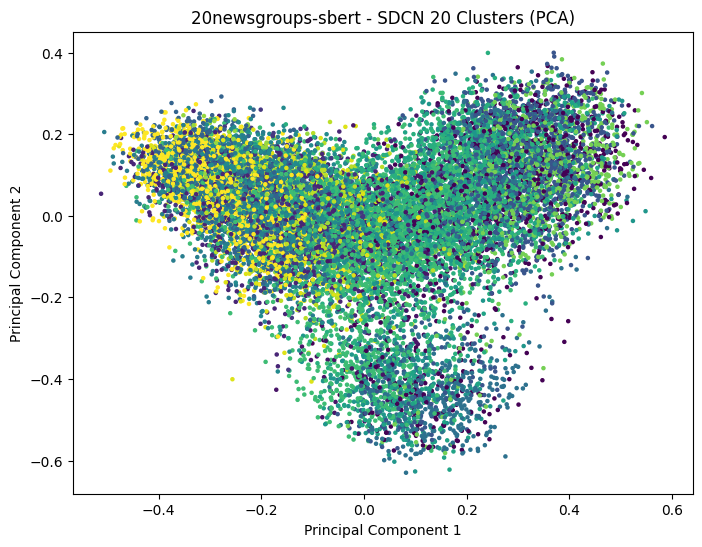


Running dataset: agnews with encoder: tfidf
[Subset] Reducing dataset from 127600 to 20000
[Graph] Nodes: 20000
[Graph] Edges: 179426
[Graph] Density: 0.00044856

[SDCN] Pretraining AE...


[SDCN] Joint Training...

[SDCN] Epoch 0 | Loss=2.1000 | KL=0.0133 | GCN_KL=0.0590 | RE=0.0034
[SDCN] Epoch 10 | Loss=3.0778 | KL=0.0308 | GCN_KL=0.1090 | RE=0.0034
[SDCN] Epoch 20 | Loss=2.8964 | KL=0.0373 | GCN_KL=0.0955 | RE=0.0034
[SDCN] Epoch 30 | Loss=2.2703 | KL=0.0320 | GCN_KL=0.0609 | RE=0.0034
[SDCN] Epoch 40 | Loss=2.5843 | KL=0.0431 | GCN_KL=0.0750 | RE=0.0034
[SDCN] Epoch 50 | Loss=2.8382 | KL=0.0514 | GCN_KL=0.0868 | RE=0.0033
[SDCN] Epoch 60 | Loss=3.1872 | KL=0.0624 | GCN_KL=0.1029 | RE=0.0033
[SDCN] Epoch 70 | Loss=3.5050 | KL=0.0723 | GCN_KL=0.1175 | RE=0.0033
[SDCN] Epoch 80 | Loss=3.9421 | KL=0.0835 | GCN_KL=0.1385 | RE=0.0033
[SDCN] Epoch 90 | Loss=4.5821 | KL=0.0924 | GCN_KL=0.1724 | RE=0.0033
[SDCN] Epoch 100 | Loss=5.2421 | KL=0.1014 | GCN_KL=0.2073 | RE=0.0033
[SDCN] Epoch 

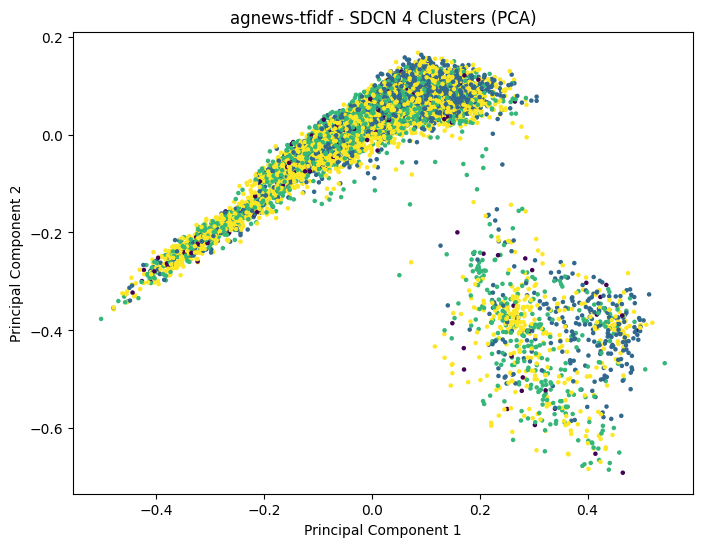

In [4]:
history = run_experiments(
    datasets_root="../embeddings",
    csv_path="../outputs/results.csv"
)